General-purpose SQD workflow for a Jordan-Wigner Pauli-list Hamiltonian file.
 
Nothing in this script is specific to any one molecule. Every physical quantity (qubit count, electron count, spin, reference energy, qubit ordering) is read from FILEPATH via parse_hamiltonian.parse_metadata(...) and parse_hamiltonian.parse_hamiltonian_file(...). To run this on a DIFFERENT Hamiltonian, you should only need to change FILEPATH below -- as long as that file follows the same header-comment conventions documented in parse_hamiltonian.py.
 
Uses qiskit-addon-sqd's generic qubit-Hamiltonian SQD routines (which work directly on a SparsePauliOp, unlike qiskit_addon_sqd.fermion which needs hcore/eri integrals we don't have access to here).

In [1]:
%pip install qiskit_addon_sqd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 18.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 109.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.2 MB/s eta 0:00:00


In [2]:
%pip install python-dotenv

In [3]:
%pip install qiskit_ibm_runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.3/113.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 33.3 MB/s eta 0:00:00


In [4]:
%pip install ffsim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 749.4/749.4 kB 11.9 MB/s eta 0:00:00a 0:00:01


In [5]:
from itertools import combinations
import json
import ffsim
import matplotlib.pyplot as plt
import numpy as np
import qiskit_addon_sqd.configuration_recovery as sqd_cr
import qiskit_addon_sqd.counts as sqd_counts
import qiskit_addon_sqd.qubit as sqd_qubit
import qiskit_addon_sqd.subsampling as sqd_sub
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import CouplingMap
from scipy.optimize import minimize

In [6]:
import os

if not os.path.exists("SQD"):
    !git clone https://github.com/KhushiPandey1805/SQD.git SQD
    print("Cloned fresh.")
else:
    os.chdir("SQD")
    !git pull
    os.chdir("/content")
    print("Already present, pulled latest changes.")

!ls /content/SQD/code

import sys
sys.path.insert(0, "/content/SQD/code")

from hamiltonianCode import (
    interleaved_to_blocked_layout,
    parse_hamiltonian_file,
    parse_metadata,
)


Cloning into 'SQD'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 116 (delta 52), reused 88 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (116/116), 756.89 KiB | 10.81 MiB/s, done.
Resolving deltas: 100% (52/52), done.
Cloned fresh.
hamiltonianCode.ipynb  hamiltonianCode.py  N2ex.ipynb  simVShardware.ipynb


In [ ]:
#only if pull fails earlier
#!rm /content/SQD/code/hamiltonianCode.py

In [ ]:
#only if pull failed and rm done
#%cd /content/SQD
#!git pull
#%cd /content

In [ ]:
# ----------------------------------------------------------------------
# ONLY THIS LINE SHOULD NEED TO CHANGE TO RUN A DIFFERENT HAMILTONIAN:
FILEPATH = "/content/SQD/hamiltonian/H2O_CAS4e4o_JW_Pauli_Hamiltonian_HERMITIAN.txt"
# ----------------------------------------------------------------------

N_REPS=2

Parse the file, remap to blocked ordering if needed, and return

(hamiltonian, metadata) where metadata also gets a few derived fields

(num_qubits, alpha_qubits, beta_qubits, hf_occupied_qubits) added.

In [ ]:
def load_hamiltonian_and_metadata(filepath: str):
    hamiltonian = parse_hamiltonian_file(filepath)
    metadata = parse_metadata(filepath)
 
    norb = metadata["n_spatial_orbitals"]
    num_qubits = hamiltonian.num_qubits
    if num_qubits != 2 * norb:
        raise ValueError(
            f"Qubit count from file body ({num_qubits}) doesn't match "
            f"2 * n_spatial_orbitals from header ({2 * norb}). "
            "Double check the file isn't corrupted or using an unexpected format."
        )
 
    if metadata["qubit_ordering"] == "interleaved":
        layout = interleaved_to_blocked_layout(norb)
        hamiltonian = hamiltonian.apply_layout(layout, num_qubits=num_qubits).simplify()
    elif metadata["qubit_ordering"] == "blocked":
        pass  # already in the ordering qiskit-addon-sqd expects
    else:
        raise ValueError(
            "Could not determine qubit ordering ('interleaved' vs 'blocked') "
            "from the file header. Add explicit handling before proceeding -- "
            "using the wrong ordering here would silently corrupt the physics."
        )
 
    metadata["num_qubits"] = num_qubits
    metadata["alpha_qubits"] = list(range(norb))
    metadata["beta_qubits"] = list(range(norb, 2 * norb))
    metadata["hf_occupied_qubits"] = (
        list(range(metadata["n_alpha"])) + list(range(norb, norb + metadata["n_beta"]))
    )
    metadata["nelec"] = (metadata["n_alpha"], metadata["n_beta"])
 
    return hamiltonian, metadata

In [ ]:
def make_default_stand_in_backend():
    """A synthetic heavy-hex backend, used only to pin down a concrete
    connectivity when just testing/optimizing (e.g. on the simulator path).
    For the REAL hardware run, pass the actual selected backend instead."""
    coupling_map = CouplingMap.from_heavy_hex(3)
    return GenericBackendV2(
        coupling_map.size(), coupling_map=coupling_map,
        basis_gates=["cp", "xx_plus_yy", "p", "x", "swap"],
    )

In [ ]:
def build_lucj_pass_manager(backend, norb):
    pairs_aa = [(p, p + 1) for p in range(norb - 1)]
    pass_manager, pairs_ab = ffsim.qiskit.generate_lucj_pass_manager(
        backend=backend, norb=norb, connectivity="heavy-hex",
        interaction_pairs=(pairs_aa, None), optimization_level=3,
    )
    return pass_manager, pairs_aa, pairs_ab

In [ ]:
def build_lucj_circuit(params, norb, nelec, pairs_aa, pairs_ab, n_reps=N_REPS):
    ucj_op = ffsim.UCJOpSpinBalanced.from_parameters(
        params, norb=norb, n_reps=n_reps, interaction_pairs=(pairs_aa, pairs_ab),
    )
    qubits = QuantumRegister(2 * norb, name="q")
    circuit = QuantumCircuit(qubits)
    circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)
    circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
    return circuit

In [ ]:
def optimize_lucj_ansatz(hamiltonian, norb, nelec, pairs_aa, pairs_ab, n_reps=N_REPS,
                          seed=1, maxiter=3000):
    """Classically optimize LUCJ parameters against the exact Hamiltonian --
    our substitute for CCSD-amplitude seeding, since hcore/eri are not
    available for this system (confirmed with the file we were given)."""
    estimator = StatevectorEstimator()
 
    def energy(params):
        qc = build_lucj_circuit(params, norb, nelec, pairs_aa, pairs_ab, n_reps)
        return float(estimator.run([(qc, hamiltonian)]).result()[0].data.evs)
 
    template_op = ffsim.random.random_ucj_op_spin_balanced(norb, n_reps=n_reps, seed=0)
    n_params = len(template_op.to_parameters(interaction_pairs=(pairs_aa, pairs_ab)))
    rng = np.random.default_rng(seed)
    x0 = rng.normal(scale=0.1, size=n_params)
    return minimize(energy, x0, method="COBYLA", options={"maxiter": maxiter, "rhobeg": 0.3})

In [ ]:
def sweep_n_reps(hamiltonian, meta, pass_manager, pairs_aa, pairs_ab,
                  candidate_reps=(1, 2, 3), max_two_qubit_depth=None, seed=1):
    """
    Reproducibly choose n_reps by actually testing candidates, rather than
    hardcoding a value chosen from one-off exploration outside the repo.
 
    For each candidate: build + classically optimize the LUCJ ansatz, then
    transpile to get its REAL two-qubit depth (against `pass_manager`'s
    backend). Prints the full accuracy-vs-depth table so the trade-off is
    visible and auditable, not hidden inside a chosen constant.
 
    Selection rule (documented, not implicit): among candidates whose
    two-qubit depth is <= max_two_qubit_depth (if given), pick the one with
    the lowest energy error. If none satisfy the depth cap, or no cap is
    given, pick the lowest energy error overall. Ties broken by lower depth.
    """
    norb = meta["n_spatial_orbitals"]
    nelec = meta["nelec"]
    reference_energy = meta["reference_energy"]
 
    results = []
    for n_reps in candidate_reps:
        opt_result = optimize_lucj_ansatz(hamiltonian, norb, nelec, pairs_aa, pairs_ab,
                                           n_reps=n_reps, seed=seed)
        circuit = build_lucj_circuit(opt_result.x, norb, nelec, pairs_aa, pairs_ab, n_reps)
        circuit.measure_all()
        isa_circuit = pass_manager.run(circuit)
        two_qubit_depth = isa_circuit.depth(lambda instr: instr.operation.num_qubits == 2)
        total_depth = isa_circuit.depth()
        error_mha = (opt_result.fun - reference_energy) * 1000
 
        results.append({
            "n_reps": n_reps, "opt_result": opt_result, "isa_circuit": isa_circuit,
            "two_qubit_depth": two_qubit_depth, "total_depth": total_depth,
            "error_mha": error_mha,
        })
        print(f"n_reps={n_reps}: error={error_mha:.3f} mHa, "
              f"two-qubit depth={two_qubit_depth}, total depth={total_depth}")
 
    eligible = [r for r in results if max_two_qubit_depth is None
                or r["two_qubit_depth"] <= max_two_qubit_depth]
    if not eligible:
        print(f"WARNING: no candidate had two-qubit depth <= {max_two_qubit_depth}; "
              f"selecting from all candidates instead.")
        eligible = results
 
    chosen = min(eligible, key=lambda r: (r["error_mha"], r["two_qubit_depth"]))
    print(f"\nSelected n_reps={chosen['n_reps']} "
          f"(error={chosen['error_mha']:.3f} mHa, "
          f"two-qubit depth={chosen['two_qubit_depth']})")
    return chosen, results

In [ ]:
def sample_circuit(sampler, circuit, shots: int, label: str, backend=None):
    job = sampler.run([circuit], shots=shots)
    bit_array = job.result()[0].data.meas
    bitstring_matrix, probs = sqd_counts.bit_array_to_arrays(bit_array)
 
    run_record = {
        "label": label,
        "shots": shots,
        "num_unique_bitstrings": int(bitstring_matrix.shape[0]),
        "circuit_total_depth": circuit.depth(),
        "circuit_two_qubit_depth": circuit.depth(lambda instr: instr.operation.num_qubits == 2),
        "circuit_gate_counts": dict(circuit.count_ops()),
    }
 
    if backend is not None:
        job_id = job.job_id()
        run_record["backend_name"] = backend.name
        run_record["job_id"] = job_id
        try:
            run_record["physical_qubit_layout"] = list(circuit.layout.final_index_layout())
        except Exception:
            run_record["physical_qubit_layout"] = None
        run_record["raw_counts"] = bit_array.get_counts()

        # <<< PRINT THE DETAILS DIRECTLY >>>
        print(f"[{label}] backend name: {run_record['backend_name']}")
        print(f"[{label}] job ID: {run_record['job_id']}")
        print(f"[{label}] physical qubit layout: {run_record['physical_qubit_layout']}")
        print(f"[{label}] number of distinct raw bitstrings observed: "
              f"{len(run_record['raw_counts'])}")
        print(f"[{label}] raw counts (first 5 entries): "
              f"{dict(list(run_record['raw_counts'].items())[:5])}")
        # <<< END PRINT >>>

        results_path = os.path.abspath(f"hardware_run_{job_id}.json")
        with open(results_path, "w") as f:
            json.dump(run_record, f, indent=2, default=str)
        print(f"[{label}] saved run metadata to: {results_path}")

        calibration = job.properties()
        if calibration is not None:
            calib_path = os.path.abspath(f"calibration_{job_id}.json")
            with open(calib_path, "w") as f:
                json.dump(calibration.to_dict(), f, indent=2, default=str)
            print(f"[{label}] saved backend calibration to: {calib_path}")
        else:
            print(f"[{label}] WARNING: no calibration snapshot available for this job.")
 
    print(f"[{label}] unique sampled bitstrings: {bitstring_matrix.shape[0]}  "
          f"(2q depth: {run_record['circuit_two_qubit_depth']}, "
          f"total depth: {run_record['circuit_total_depth']})")
    return bitstring_matrix, probs, run_record

In [ ]:
def report_validity_fractions(bitstring_matrix, probs, meta, label: str):
    norb = meta["n_spatial_orbitals"]
    n_alpha, n_beta = meta["n_alpha"], meta["n_beta"]
    valid_mask = (
        (bitstring_matrix[:, :norb].sum(axis=1) == n_beta)
        & (bitstring_matrix[:, norb:].sum(axis=1) == n_alpha)
    )
    fraction_of_shots = float(probs[valid_mask].sum())
    fraction_of_unique_bitstrings = float(valid_mask.sum() / len(valid_mask))
    print(f"[{label}] fraction of TOTAL SHOTS in correct sector: {fraction_of_shots:.4f}")
    print(f"[{label}] fraction of DISTINCT bitstrings that are valid: "
          f"{fraction_of_unique_bitstrings:.4f}")
    return fraction_of_shots, fraction_of_unique_bitstrings

In [ ]:
def run_sqd_postprocessing(hamiltonian, meta, bitstring_matrix, probs,
                            n_iterations: int = 5, samples_per_batch: int = 20,
                            num_batches: int = 3, seed: int = 0, verbose: bool = True,
                            label: str = "run"):
    norb = meta["n_spatial_orbitals"]
    n_alpha, n_beta = meta["n_alpha"], meta["n_beta"]
 
    avg_occ_a = np.array([1.0] * n_alpha + [0.0] * (norb - n_alpha))
    avg_occ_b = np.array([1.0] * n_beta + [0.0] * (norb - n_beta))
 
    energy_history = []
    for it in range(n_iterations):
        bs_recovered, probs_recovered = sqd_cr.recover_configurations(
            bitstring_matrix, probs, (avg_occ_a, avg_occ_b),
            num_elec_a=n_alpha, num_elec_b=n_beta, rand_seed=seed + it,
        )
        bs_post, probs_post = sqd_sub.postselect_by_hamming_right_and_left(
            bs_recovered, probs_recovered, hamming_right=n_alpha, hamming_left=n_beta,
        )
        this_batch_size = min(samples_per_batch, bs_post.shape[0])
        batches = sqd_sub.subsample(
            bs_post, probs_post, samples_per_batch=this_batch_size,
            num_batches=num_batches, rand_seed=seed + it,
        )
 
        best_energy, best_vec, best_bs = None, None, None
        for batch in batches:
            batch_sorted = sqd_qubit.sort_and_remove_duplicates(batch)
            eigvals, eigvecs = sqd_qubit.solve_qubit(batch_sorted, hamiltonian, k=1)
            if best_energy is None or eigvals[0] < best_energy:
                best_energy, best_vec, best_bs = eigvals[0], eigvecs[:, 0], batch_sorted
 
        weights = np.abs(best_vec) ** 2
        occ_by_qubit = ((weights[:, None] * best_bs).sum(axis=0))[::-1]
        avg_occ_a = occ_by_qubit[:norb]
        avg_occ_b = occ_by_qubit[norb:]
 
        energy_history.append(best_energy)
        if verbose:
            error_mha = (best_energy - meta["reference_energy"]) * 1000
            print(f"[{label}] iter {it}: energy={best_energy:.6f}  error={error_mha:.3f} mHa")
 
    return energy_history

In [ ]:
def shot_dependence_study(hamiltonian, meta, bitstring_matrix, probs,
                           subsample_sizes, n_seeds: int = 5, label: str = "run"):
    rng = np.random.default_rng(12345)
    results = {}
    for n_shots_sub in subsample_sizes:
        final_energies = []
        for seed_i in range(n_seeds):
            draw = rng.choice(len(bitstring_matrix), size=n_shots_sub, p=probs, replace=True)
            unique_idx, counts = np.unique(draw, return_counts=True)
            sub_bitstrings = bitstring_matrix[unique_idx]
            sub_probs = counts / counts.sum()
            history = run_sqd_postprocessing(
                hamiltonian, meta, sub_bitstrings, sub_probs,
                n_iterations=3, samples_per_batch=20, num_batches=3,
                seed=seed_i, verbose=False, label=label,
            )
            final_energies.append(history[-1])
        mean_e, std_e = float(np.mean(final_energies)), float(np.std(final_energies))
        results[n_shots_sub] = (mean_e, std_e)
        error_mha = (mean_e - meta["reference_energy"]) * 1000
        print(f"[{label}] n_shots={n_shots_sub}: mean energy={mean_e:.6f} +/- {std_e:.6f}  "
              f"(mean error={error_mha:.3f} mHa, n_seeds={n_seeds})")
    return results

In [ ]:
def batch_size_sweep(hamiltonian, meta, bitstring_matrix, probs,
                      batch_sizes, n_seeds: int = 5, label: str = "run"):
    n_alpha, n_beta = meta["n_alpha"], meta["n_beta"]
    bs_post, probs_post = sqd_sub.postselect_by_hamming_right_and_left(
        bitstring_matrix, probs, hamming_right=n_alpha, hamming_left=n_beta,
    )
    n_available = sqd_qubit.sort_and_remove_duplicates(bs_post).shape[0]
    print(f"[{label}] valid unique configurations available for sweep: {n_available}")
 
    results = {}
    for size in batch_sizes:
        this_size = min(size, n_available)
        # Probability-weighted subsampling (matches real SQD batching) -- NOT
        # uniform random choice, which can miss dominant configurations at
        # small sizes and produce non-monotonic, misleading swings.
        batches = sqd_sub.subsample(
            bs_post, probs_post, samples_per_batch=this_size,
            num_batches=n_seeds, rand_seed=1000,
        )
        energies = []
        for batch in batches:
            batch_sorted = sqd_qubit.sort_and_remove_duplicates(batch)
            eigvals, _ = sqd_qubit.solve_qubit(batch_sorted, hamiltonian, k=1)
            energies.append(eigvals[0])
        mean_e = float(np.mean(energies))
        error_mha = (mean_e - meta["reference_energy"]) * 1000
        results[size] = error_mha
        print(f"[{label}] samples_per_batch={size} (actual used={this_size}): "
              f"mean error={error_mha:.4f} mHa  (n_seeds={n_seeds})")
    return results

In [ ]:
def plot_batch_sweep(sweep_results: dict, title: str):
    fig, ax = plt.subplots(figsize=(7, 5))
    for label, results in sweep_results.items():
        sizes = sorted(results.keys())
        errors = [abs(results[s]) / 1000 for s in sizes]
        ax.plot(sizes, errors, marker="o", label=label)
    ax.set_yscale("log")
    ax.set_xlabel("samples_per_batch (subspace size)")
    ax.set_ylabel("|Energy error| vs. exact diagonalization (Ha)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig("batch_size_sweep.png", dpi=150)
    print("Saved plot to batch_size_sweep.png")

In [ ]:
def plot_before_after_sqd(pre_sqd_energy: float, post_sqd_by_label: dict,
                           reference_energy: float, title: str):
    fig, ax = plt.subplots(figsize=(7, 5))
    labels = list(post_sqd_by_label.keys())
    x = np.arange(len(labels))
    ax.axhline(reference_energy, color="black", linestyle="--", label="exact CASSCF")
    ax.axhline(pre_sqd_energy, color="gray", linestyle=":", label="pre-SQD (ansatz only)")
    ax.scatter(x, [post_sqd_by_label[l] for l in labels], color="#BF5700",
               zorder=5, s=80, label="post-SQD")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Energy (Ha)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig("before_after_sqd.png", dpi=150)
    print("Saved plot to before_after_sqd.png")

In [23]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager 
from getpass import getpass 

token = getpass("IBM Quantum API token: ") 
crn = getpass("CRN: ")

QiskitRuntimeService.save_account(
    token=token,
    instance=crn,
    channel="ibm_quantum_platform",
    overwrite=True,
    set_as_default=True
)

In [24]:
def main():
    hamiltonian, meta = load_hamiltonian_and_metadata(FILEPATH)
    norb, nelec = meta["n_spatial_orbitals"], meta["nelec"]
    print(f"Loaded Hamiltonian: {meta['num_qubits']} qubits, {meta['n_electrons']} electrons "
          f"(n_alpha={meta['n_alpha']}, n_beta={meta['n_beta']}), "
          f"reference energy={meta['reference_energy']}\n")
 
    # ---- Build LUCJ pass manager against a stand-in heavy-hex backend for
    # optimization/testing. For the REAL hardware run, rebuild this against
    # the actual selected `backend` instead (see commented block below). ----
    stand_in_backend = make_default_stand_in_backend()
    pass_manager, pairs_aa, pairs_ab = build_lucj_pass_manager(stand_in_backend, norb)
 
    # Reproducibly choose n_reps by actually sweeping candidates, rather than
    # trusting a hardcoded constant. This prints the full trade-off table.
    chosen, sweep_results = sweep_n_reps(
        hamiltonian, meta, pass_manager, pairs_aa, pairs_ab, candidate_reps=(1, 2, 3),
    )
    opt_result = chosen["opt_result"]
    isa_circuit = chosen["isa_circuit"]
    pre_sqd_energy = opt_result.fun
    print(f"\nPre-SQD (optimized LUCJ ansatz, n_reps={chosen['n_reps']}) energy: "
          f"{pre_sqd_energy:.6f}  (error {chosen['error_mha']:.3f} mHa)\n")
 
    # ---------------- SIMULATOR ----------------
    SHOTS = 10_000
    sim_sampler = StatevectorSampler(seed=np.random.default_rng(0))
    sim_bs, sim_probs, _ = sample_circuit(sim_sampler, isa_circuit, shots=SHOTS, label="simulator")
    report_validity_fractions(sim_bs, sim_probs, meta, label="simulator")
    sim_history = run_sqd_postprocessing(hamiltonian, meta, sim_bs, sim_probs, label="simulator")
 
    # ---------------- REAL HARDWARE ----------------
    service = QiskitRuntimeService(channel="ibm_quantum_platform")
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=meta["num_qubits"])
    
    # # Rebuild the pass manager against the REAL backend (connectivity/native
    # # gates differ from our stand-in) -- same circuit/parameters, retranspiled.
    hw_pass_manager, hw_pairs_aa, hw_pairs_ab = build_lucj_pass_manager(backend, norb)
    hw_opt_result = optimize_lucj_ansatz(hamiltonian, norb, nelec, hw_pairs_aa, hw_pairs_ab,
                                      n_reps=chosen["n_reps"])
    hw_circuit = build_lucj_circuit(hw_opt_result.x, norb, nelec, hw_pairs_aa, hw_pairs_ab,
                                 n_reps=chosen["n_reps"])
    hw_circuit.measure_all()
    isa_circuit = hw_pass_manager.run(hw_circuit)

    hw_sampler = SamplerV2(mode=backend)
    hw_bs, hw_probs, hw_record = sample_circuit(hw_sampler, isa_circuit, shots=SHOTS,
                                                  label="hardware", backend=backend)
    report_validity_fractions(hw_bs, hw_probs, meta, label="hardware")
    hw_history = run_sqd_postprocessing(hamiltonian, meta, hw_bs, hw_probs, label="hardware")
    
    subsample_sizes = [500, 1000, 2000, 5000, 10000]
    shot_dependence_study(hamiltonian, meta, sim_bs, sim_probs, subsample_sizes, label="simulator")
    shot_dependence_study(hamiltonian, meta, hw_bs, hw_probs, subsample_sizes, label="hardware")
    
    batch_sizes = [5, 10, 15, 20, 25, 30, 36]
    sim_sweep = batch_size_sweep(hamiltonian, meta, sim_bs, sim_probs, batch_sizes, label="simulator")
    hw_sweep = batch_size_sweep(hamiltonian, meta, hw_bs, hw_probs, batch_sizes, label="hardware")
    plot_batch_sweep({"simulator": sim_sweep, "hardware": hw_sweep},
                       title="SQD error vs. subspace size (H2O CAS(4e,4o))")
    
    plot_before_after_sqd(
         pre_sqd_energy, {"simulator": sim_history[-1], "hardware": hw_history[-1]},
         meta["reference_energy"], title="Pre-SQD vs. post-SQD vs. exact (H2O CAS(4e,4o))",
     )

Loaded Hamiltonian: 8 qubits, 4 electrons (n_alpha=2, n_beta=2), reference energy=-76.11669094458742

n_reps=1: error=32.571 mHa, two-qubit depth=11, total depth=14
n_reps=2: error=9.236 mHa, two-qubit depth=19, total depth=23
n_reps=3: error=7.151 mHa, two-qubit depth=27, total depth=32

Selected n_reps=3 (error=7.151 mHa, two-qubit depth=27)

Pre-SQD (optimized LUCJ ansatz, n_reps=3) energy: -76.109540  (error 7.151 mHa)

[simulator] unique sampled bitstrings: 15  (2q depth: 27, total depth: 32)
[simulator] fraction of TOTAL SHOTS in correct sector: 1.0000
[simulator] fraction of DISTINCT bitstrings that are valid: 1.0000
[simulator] iter 0: energy=-76.114195  error=2.496 mHa
[simulator] iter 1: energy=-76.114195  error=2.496 mHa
[simulator] iter 2: energy=-76.114195  error=2.496 mHa
[simulator] iter 3: energy=-76.114195  error=2.496 mHa
[simulator] iter 4: energy=-76.114195  error=2.496 mHa


/tmp/ipykernel_1940/2011446383.py:46: DeprecationWarning: The SamplerV2 class is deprecated as of qiskit-ibm-runtime 0.50.0 and will be removed no sooner than 3 months after the release date. `qiskit_ibm_runtime.executor_sampler.Sampler` provides a new Sampler implementation that runs all the pre- and post-processing in the client side. The top-level `qiskit_ibm_runtime.Sampler` import will be updated to point to the client-side sampler in an upcoming release, with the legacy Sampler being available until the deprecation is completed.
  hw_sampler = SamplerV2(mode=backend)


[hardware] backend name: ibm_fez
[hardware] job ID: daroq5bg95ks73eelcog
[hardware] physical qubit layout: [109, 110, 111, 112, 107, 106, 105, 104]
[hardware] number of distinct raw bitstrings observed: 248
[hardware] raw counts (first 5 entries): {'00110011': 3295, '00111011': 351, '11001010': 5, '10111111': 10, '00111000': 168}
[hardware] saved run metadata to: /content/hardware_run_daroq5bg95ks73eelcog.json
[hardware] saved backend calibration to: /content/calibration_daroq5bg95ks73eelcog.json
[hardware] unique sampled bitstrings: 248  (2q depth: 60, total depth: 231)
[hardware] fraction of TOTAL SHOTS in correct sector: 0.4788
[hardware] fraction of DISTINCT bitstrings that are valid: 0.1452
[hardware] iter 0: energy=-76.111916  error=4.775 mHa
[hardware] iter 1: energy=-76.103284  error=13.407 mHa
[hardware] iter 2: energy=-76.103713  error=12.978 mHa
[hardware] iter 3: energy=-76.102575  error=14.116 mHa
[hardware] iter 4: energy=-76.105223  error=11.467 mHa
[simulator] n_shots=5

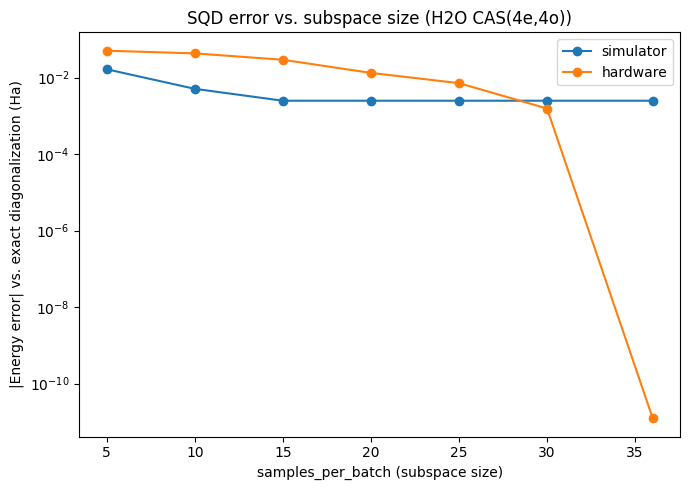

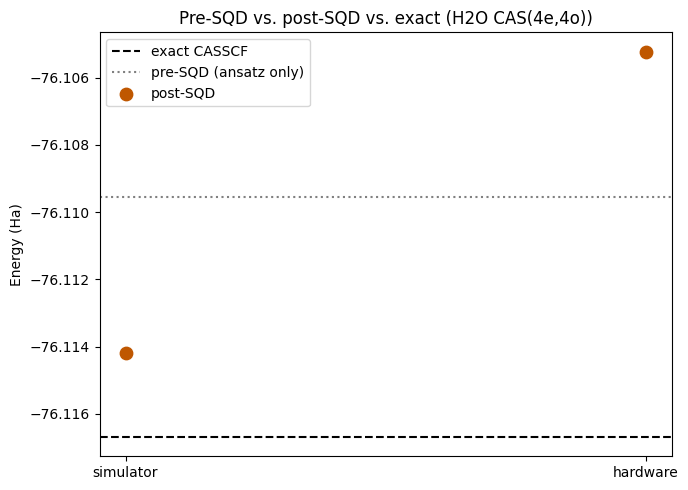

In [25]:
if __name__ == "__main__":
    main()